In [1]:
# Bibliotecas essenciais para manipulação de dados e modelagem
import numpy as np
import pandas as pd

# Dataset de câncer de mama (classificação binária)
from sklearn.datasets import load_breast_cancer

# Divisão dos dados
from sklearn.model_selection import train_test_split

# Padronização — crucial para SVM
from sklearn.preprocessing import StandardScaler

# PCA — redução de dimensionalidade para visualização
from sklearn.decomposition import PCA

# Modelos
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Carrega o dataset
data = load_breast_cancer()

# Cria DataFrame para facilitar a análise
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Exibe informações iniciais
print("Formato dos dados:", X.shape)
print("Classes:", np.unique(y))
X.head()


Formato dos dados: (569, 30)
Classes: [0 1]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


O dataset Breast Cancer é amplamente utilizado em benchmarks de classificação. Ele contém 30 variáveis numéricas relacionadas a características de tumores, com o objetivo de prever se são malignos ou benignos.

In [3]:
# Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


O parâmetro stratify=y garante que a proporção das classes seja mantida no treino e teste, evitando viés na avaliação.

In [4]:
scaler = StandardScaler()

# SVM exige padronização devido à sensibilidade à escala
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


A padronização é essencial para modelos baseados em distância, como o SVM.
Já o XGBoost não depende da escala, pois utiliza árvores de decisão.

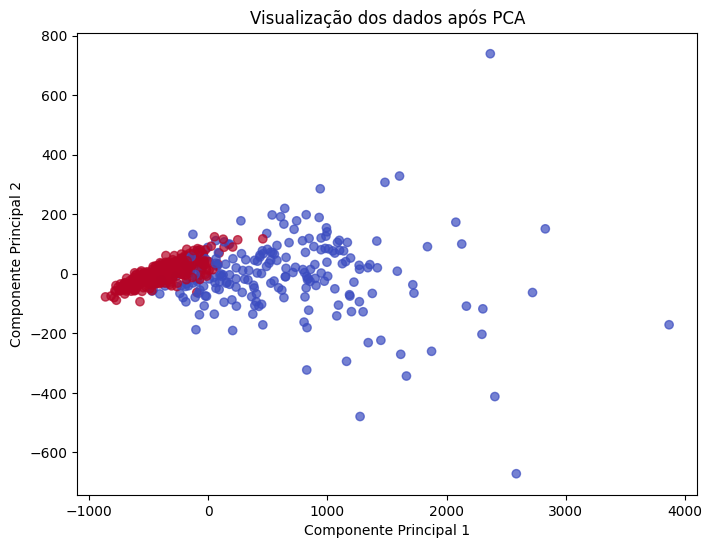

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', alpha=0.7)
plt.title("Visualização dos dados após PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()


O PCA reduz os dados para duas dimensões, permitindo visualizar a separação natural entre as classes.
Embora não seja usado diretamente na modelagem, ele ajuda a interpretar a estrutura dos dados.

In [6]:
svm = SVC(kernel='rbf', C=1, probability=True)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("Acurácia do SVM:", acc_svm)


Acurácia do SVM: 0.9824561403508771


O kernel RBF é adequado para dados não linearmente separáveis.
O hiperparâmetro C controla o equilíbrio entre margem larga e penalização de erros.

In [7]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("Acurácia do XGBoost:", acc_xgb)


Acurácia do XGBoost: 0.9473684210526315


O XGBoost é um modelo baseado em boosting, altamente eficiente para grandes volumes de dados.
Ele costuma superar modelos lineares em problemas complexos.

In [8]:
print(f"Acurácia SVM: {acc_svm:.4f}")
print(f"Acurácia XGBoost: {acc_xgb:.4f}")


Acurácia SVM: 0.9825
Acurácia XGBoost: 0.9474


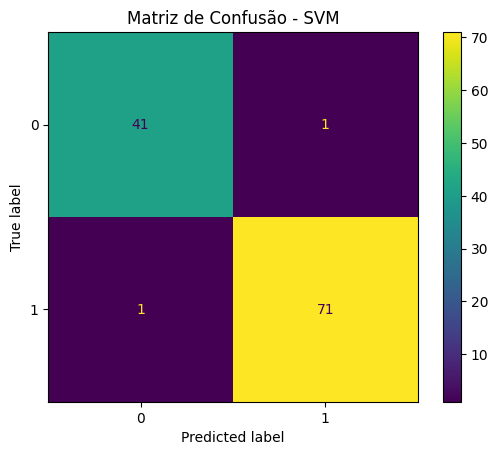

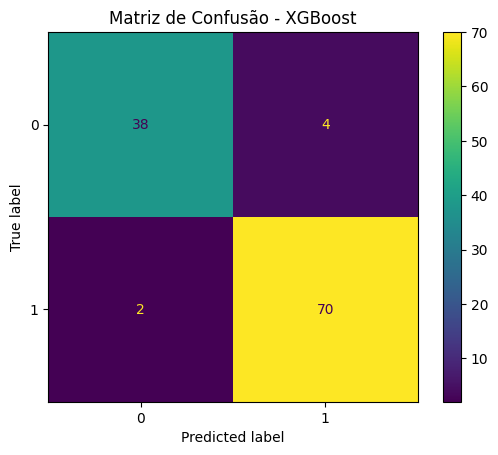

In [9]:
# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(cm_svm)
disp_svm.plot()
plt.title("Matriz de Confusão - SVM")
plt.show()

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(cm_xgb)
disp_xgb.plot()
plt.title("Matriz de Confusão - XGBoost")
plt.show()


A matriz de confusão permite avaliar erros específicos, como falsos positivos e falsos negativos — essenciais em problemas médicos.

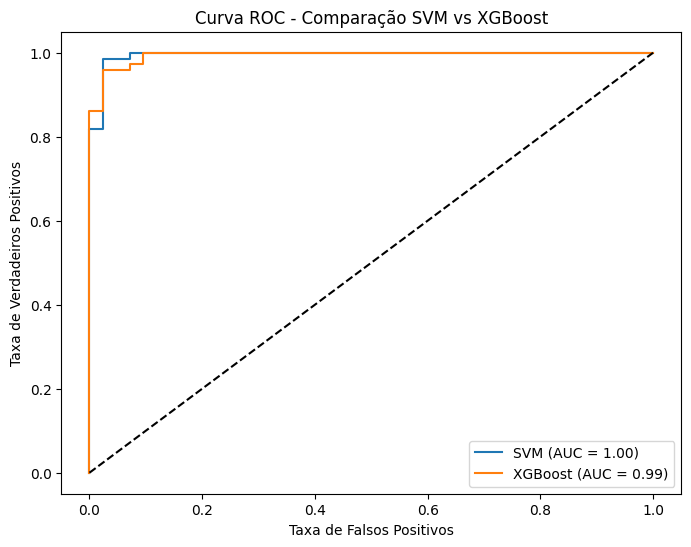

In [10]:
# SVM
y_prob_svm = svm.predict_proba(X_test_scaled)[:,1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# XGBoost
y_prob_xgb = xgb.predict_proba(X_test)[:,1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {roc_auc_svm:.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_xgb:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC - Comparação SVM vs XGBoost")
plt.legend()
plt.show()


A curva ROC e o AUC são métricas robustas para avaliar modelos de classificação binária, especialmente quando há desbalanceamento.

Este projeto tem como objetivo comparar dois modelos de Machine Learning muito usados em classificação: SVM e XGBoost.
Utilizamos o conjunto de dados de câncer de mama, que contém informações sobre tumores e indica se eles são benignos ou malignos.

Primeiro, os dados foram preparados e padronizados, já que o SVM é sensível à escala das variáveis. Depois, aplicamos o PCA para reduzir a dimensionalidade e visualizar melhor a separação entre as classes. Em seguida, treinamos os dois modelos e avaliamos o desempenho de cada um usando métricas como acurácia, matriz de confusão e curva ROC.

Por fim, comparamos os resultados e observamos qual modelo teve melhor desempenho. Essa análise ajuda a entender como diferentes algoritmos se comportam no mesmo problema e quais são suas vantagens.

In [12]:
plt.savefig("arquivo_pca.png")


<Figure size 640x480 with 0 Axes>